# Symbolic Aggregate approXimation (SAX)

Symbolic Aggregate approXimation (SAX) converts a real-valued time series into a compact symbolic representation. It first reduces the series with Piecewise Aggregate Approximation (PAA), then maps each reduced value to a symbol using distribution-based breakpoints.

This notebook demonstrates the `aeon` SAX transformer with a custom alphabet, inverse reconstruction, and optional sliding-window transformation.

## Table of contents

1. [Imports](#imports)
2. [Load an example dataset](#load-an-example-dataset)
3. [Standard SAX transformation](#standard-sax-transformation)
4. [Visualise the SAX representation](#visualise-the-sax-representation)
5. [Windowed SAX transformation](#windowed-sax-transformation)
6. [Visualise a windowed SAX word](#visualise-a-windowed-sax-word)
7. [Summary](#summary)

## What you will learn

- How SAX represents a time series as a word of symbols.
- How Gaussian breakpoints determine the assigned symbols.
- How to reconstruct an approximate series with `inverse_sax`.
- How windowing produces one SAX word per sliding window.


## Imports

Import the numerical, plotting, and `aeon` utilities used throughout the notebook.

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.stats import norm

from aeon.datasets import load_classification
from aeon.transformations.collection.dictionary_based import SAX

## Load an example dataset

We use the univariate `ArrowHead` classification dataset. `aeon` stores collections in a three-dimensional array with shape `(n_cases, n_channels, n_timepoints)`.

In [23]:
X_train, y_train = load_classification(name="ArrowHead", split="train")

print(f"Training data shape: {X_train.shape}")
print(f"Class labels: {np.unique(y_train)}")

Training data shape: (36, 1, 251)
Class labels: ['0' '1' '2']


## Standard SAX transformation

For the standard transformation, the full series is reduced to `n_segments` PAA values. Each value is assigned to one of `alphabet_size` Gaussian intervals and replaced by the corresponding alphabet element.

With `n_segments=8`, each input series becomes one SAX word containing eight symbols.

In [24]:
n_segments = 8
alphabet_size = 4
alphabet = ["a", "b", "c", "d"]

sax = SAX(
    n_segments=n_segments,
    alphabet_size=alphabet_size,
    alphabet=alphabet,
)

X_sax = sax.fit_transform(X_train)
X_sax_inverse = sax.inverse_sax(
    X_sax,
    original_length=X_train.shape[-1],
)

print(f"SAX output shape: {X_sax.shape}")
print(f"Inverse SAX output shape: {X_sax_inverse.shape}")
print("First SAX word:", X_sax[0, 0])

SAX output shape: (36, 1, 8)
Inverse SAX output shape: (36, 1, 251)
First SAX word: ['a' 'd' 'c' 'b' 'b' 'c' 'd' 'a']


## Visualise the SAX representation

The plot below combines four views of the transformation:

- the original series;
- the inverse SAX approximation;
- the symbol assigned to each PAA segment;
- the Gaussian distribution and its SAX breakpoints, denoted by $\beta_i$.

The inverse curve is an approximation rather than an exact reconstruction because each symbol represents an interval of values.

In [25]:
def plot_sax_representation(
    X,
    X_sax,
    X_inverse,
    sax,
    series_index=0,
    channel_index=0,
    window_index=None,
):
    """Plot a standard SAX word or one selected word from windowed SAX."""
    n_timepoints = X.shape[-1]
    timepoints = np.arange(n_timepoints)

    original_series = X[series_index, channel_index]
    inverse_series = X_inverse[series_index, channel_index]
    is_windowed = X_sax.ndim == 4

    if is_windowed:
        if window_index is None:
            window_index = 0

        n_windows = X_sax.shape[2]
        if not 0 <= window_index < n_windows:
            raise IndexError(f"window_index must be between 0 and {n_windows - 1}")

        window_size = sax.window_size
        stride = window_size if sax.stride is None else sax.stride
        window_start = window_index * stride
        window_end = min(window_start + window_size, n_timepoints)

        segment_symbols = X_sax[
            series_index,
            channel_index,
            window_index,
        ]

        local_boundaries = np.linspace(
            0,
            window_size,
            sax.n_segments + 1,
            dtype=int,
        )
        segment_boundaries = window_start + local_boundaries
        segment_boundaries[-1] = window_end
    else:
        n_windows = None
        window_start = 0
        window_end = n_timepoints
        segment_symbols = X_sax[series_index, channel_index]
        segment_boundaries = np.linspace(
            0,
            n_timepoints,
            sax.n_segments + 1,
            dtype=int,
        )

    fig, ax = plt.subplots(figsize=(12, 5))

    ax.plot(
        timepoints,
        original_series,
        label="Original series",
        color="#86BBD8",
        linewidth=3.5,
        zorder=2,
    )
    ax.plot(
        timepoints,
        inverse_series,
        label="Inverse SAX approximation",
        color="#D95F59",
        linestyle=":",
        linewidth=4,
        alpha=0.75,
        zorder=3,
    )

    if is_windowed:
        ax.axvspan(
            window_start,
            window_end - 1,
            color="#F4D6A0",
            alpha=0.18,
            zorder=0,
            label=f"SAX window {window_index + 1}",
        )
        ax.axvline(
            window_start,
            color="black",
            linewidth=1.4,
            alpha=0.5,
            zorder=1,
        )
        ax.axvline(
            window_end - 1,
            color="black",
            linewidth=1.4,
            alpha=0.5,
            zorder=1,
        )

    for segment_index, symbol in enumerate(segment_symbols):
        start = segment_boundaries[segment_index]
        end = segment_boundaries[segment_index + 1]

        if end <= start:
            continue

        if segment_index > 0:
            ax.axvline(
                start,
                color="gray",
                linestyle="--",
                linewidth=1,
                alpha=0.4,
                zorder=1,
            )

        center = (start + end - 1) / 2
        midpoint = min(int(round(center)), n_timepoints - 1)
        segment_value = inverse_series[midpoint]

        ax.annotate(
            str(symbol),
            xy=(center, segment_value),
            xytext=(0, 15),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=18,
            fontweight="bold",
            color="black",
            zorder=20,
            annotation_clip=False,
            bbox={
                "boxstyle": "round,pad=0.2",
                "facecolor": "white",
                "edgecolor": "none",
                "alpha": 0.9,
            },
        )

    for breakpoint_index, breakpoint in enumerate(sax.breakpoints):
        ax.axhline(
            breakpoint,
            color="gray",
            linestyle="--",
            linewidth=1.2,
            alpha=0.55,
            zorder=1,
        )
        ax.text(
            int(0.05 * n_timepoints),
            breakpoint,
            rf"$\beta_{{{breakpoint_index + 1}}} = {breakpoint:.2f}$",
            ha="right",
            va="bottom",
            fontsize=9,
            color="dimgray",
            zorder=8,
        )

    title = "Original series and SAX approximation"
    if is_windowed:
        title += (
            f" — window {window_index + 1}/{n_windows} "
            f"[{window_start}:{window_end}]"
        )

    ax.set_title(title, fontsize=15)
    ax.set_xlabel("Timepoint")
    ax.set_ylabel("Value")
    ax.legend(loc="lower center")
    ax.grid(alpha=0.15)

    divider = make_axes_locatable(ax)
    ax_gaussian = divider.append_axes(
        "left",
        size="18%",
        pad=0.12,
        sharey=ax,
    )

    y_min, y_max = ax.get_ylim()
    y_values = np.linspace(y_min, y_max, 1000)
    scale = sax.distribution_params_.get("scale", 1.0)
    gaussian_density = norm.pdf(y_values, loc=0.0, scale=scale)

    ax_gaussian.plot(
        gaussian_density,
        y_values,
        color="gray",
        linewidth=2,
    )
    ax_gaussian.fill_betweenx(
        y_values,
        0,
        gaussian_density,
        color="lightgray",
        alpha=0.45,
    )

    for breakpoint in sax.breakpoints:
        ax_gaussian.axhline(
            breakpoint,
            color="gray",
            linestyle="--",
            linewidth=1.2,
            alpha=0.55,
        )

    ax_gaussian.invert_xaxis()
    ax_gaussian.set_xlabel("Density", fontsize=9)
    ax_gaussian.set_ylabel("Gaussian distribution")
    ax_gaussian.tick_params(axis="x", labelsize=8)
    ax_gaussian.tick_params(axis="y", labelleft=True)
    ax_gaussian.spines["top"].set_visible(False)
    ax_gaussian.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

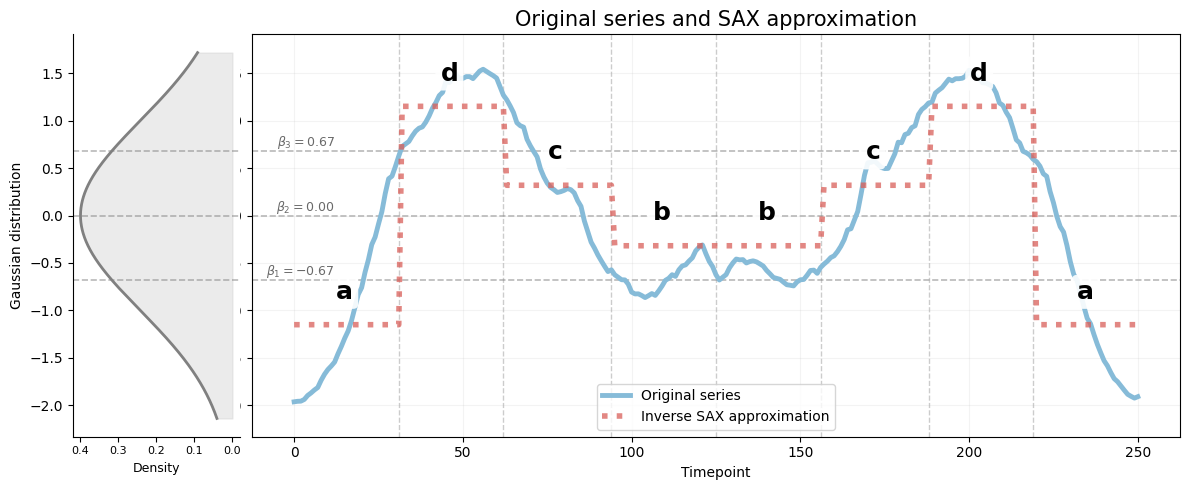

In [26]:
plot_sax_representation(
    X_train,
    X_sax,
    X_sax_inverse,
    sax,
    series_index=0,
    channel_index=0,
)

## Windowed SAX transformation

Windowing applies SAX independently to shorter subsequences rather than once to the complete series.

- `window_size` is the number of timepoints in each window.
- `stride` is the number of timepoints by which the window advances.
- Each window produces one word of length `n_segments`.

For windowed output, the array shape is

```text
(n_cases, n_channels, n_windows, n_segments)
```

When windows overlap, `inverse_sax` combines their reconstructed values by overlap averaging. A smaller stride creates more words and stronger overlap.

In [29]:
window_size = 64
stride = 1

windowed_sax = SAX(
    n_segments=n_segments,
    alphabet_size=alphabet_size,
    alphabet=alphabet,
    window_size=window_size,
    stride=stride,
)

X_windowed_sax = windowed_sax.fit_transform(X_train)
X_windowed_inverse = windowed_sax.inverse_sax(
    X_windowed_sax,
    original_length=X_train.shape[-1],
)

print(f"Windowed SAX output shape: {X_windowed_sax.shape}")
print(f"Windowed inverse output shape: {X_windowed_inverse.shape}")
print("First three SAX words for the first series:")
print(X_windowed_sax[0, 0, :3])

Windowed SAX output shape: (36, 1, 188, 8)
Windowed inverse output shape: (36, 1, 251)
First three SAX words for the first series:
[['a' 'a' 'a' 'c' 'd' 'd' 'd' 'd']
 ['a' 'a' 'b' 'c' 'd' 'd' 'd' 'd']
 ['a' 'a' 'b' 'c' 'd' 'd' 'd' 'd']]


## Visualise a windowed SAX word

The complete red curve is the overlap-averaged inverse reconstruction. The shaded region identifies the selected window, while the annotations show the symbols in that window's SAX word.

Change `window_index` to inspect another word.

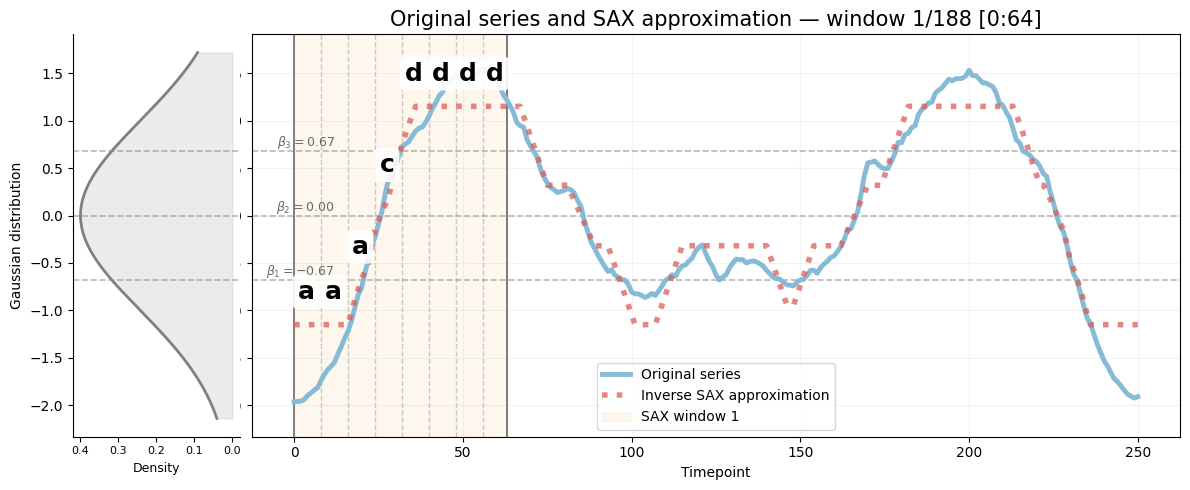

In [30]:
window_index = 0

plot_sax_representation(
    X_train,
    X_windowed_sax,
    X_windowed_inverse,
    windowed_sax,
    series_index=0,
    channel_index=0,
    window_index=window_index,
)

## Summary

SAX provides a compact and interpretable representation of time-series data:

- Standard SAX returns one symbolic word per channel and series.
- A custom alphabet changes the displayed symbols without changing the breakpoint assignment.
- The inverse transformation maps symbols to representative values and provides an approximate reconstruction.
- Windowed SAX returns one word per window and can capture local temporal patterns.
- With overlapping windows, inverse reconstruction averages the contributions at each timepoint.

The main parameters control different aspects of the representation:

| Parameter | Role |
| --- | --- |
| `n_segments` | Number of PAA sections and symbols in each word |
| `alphabet_size` | Number of Gaussian intervals and available symbols |
| `alphabet` | Optional custom labels for the intervals |
| `window_size` | Number of timepoints transformed into each word |
| `stride` | Distance between consecutive window starts |

For downstream dictionary-based methods, the windowed SAX words can be counted or compared as local symbolic patterns.